# Composite HOD prior marginalized over n(z)

The z-dependent HOD prior has `logMmin` drawn from Gaussian(mean_z, stdev_z) at each
pivot redshift, then linearly interpolated to the target z.  When testing with periodic
boxes we evaluate at a *single* snapshot (z=0.5), which is the n(z) peak — an
unrealistically tight/high-mass regime.

Here we build the **composite prior** that averages over the full observed n(z):

$$p_\text{composite}(\theta) = \int dz\, n(z)\, p_{z\text{-dep}}(\theta | z)$$

For `logMmin` this integral is done by Monte Carlo: draw $z \sim n(z)$, interpolate
`logMmin(z)` from the pivot samples, collect the marginal histogram.  All other
parameters are already z-independent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm

from cmass.bias.tools.priors import SURVEY_HOD_PRIORS

In [2]:
WDIR = '/work/hdd/bdne/maho3/cmass-ili'
PRIOR_FILE = f'{WDIR}/hod_priors/ngc.npy'
NGC_FILE = f'{WDIR}/real_data/cmass_ngc/L3000-N384/0/ngc_lightcone/hod00000_aug00000.h5'
ZPIVOT = [0.40, 0.50, 0.70]
SURVEY = 'ngc'
N_DRAW = 500_000
RNG_SEED = 42

## Load ingredients

In [3]:
# Prior samples: (N_samples,) structured array with logMmin_z0/z1/z2
prior_samples = np.load(PRIOR_FILE, allow_pickle=True)
print(
    f'Prior samples: {len(prior_samples):,}  fields: {prior_samples.dtype.names}')

# Stack into (N_samples, n_pivot) array
logMmin_pivots = np.stack(
    [prior_samples[f'logMmin_z{i}'] for i in range(len(ZPIVOT))], axis=1
)  # shape (N_samples, 3)
print(f'logMmin_pivots shape: {logMmin_pivots.shape}')

Prior samples: 1,000,000  fields: ('logMmin_z0', 'logMmin_z1', 'logMmin_z2')
logMmin_pivots shape: (1000000, 3)


In [4]:
# Observed galaxy redshifts from NGC lightcone
with h5py.File(NGC_FILE, 'r') as f:
    z_obs = f['z'][:]
print(
    f'NGC galaxies: {len(z_obs):,}  z range: [{z_obs.min():.3f}, {z_obs.max():.3f}]')

NGC galaxies: 557,850  z range: [0.400, 0.700]


## Monte Carlo marginalization over n(z)

In [5]:
rng = np.random.default_rng(RNG_SEED)

# Draw z ~ n(z) by resampling the observed catalog
z_draws = rng.choice(z_obs, size=N_DRAW, replace=True)

# Draw a prior sample (row) for each z draw
idx = rng.integers(0, len(prior_samples), size=N_DRAW)
lMmin_draws = logMmin_pivots[idx]  # (N_DRAW, 3)

# Per-sample linear interpolation: find bracket for each z, then interpolate
zpivot = np.array(ZPIVOT)
idx_bracket = np.clip(np.searchsorted(zpivot, z_draws) - 1, 0, len(zpivot) - 2)

z_lo = zpivot[idx_bracket]
z_hi = zpivot[idx_bracket + 1]
y_lo = lMmin_draws[np.arange(N_DRAW), idx_bracket]
y_hi = lMmin_draws[np.arange(N_DRAW), idx_bracket + 1]

logMmin_composite = y_lo + (y_hi - y_lo) / (z_hi - z_lo) * (z_draws - z_lo)

print(
    f'logMmin composite: mean={logMmin_composite.mean():.3f}  std={logMmin_composite.std():.3f}')
print(
    f'logMmin at z=0.5:  mean={prior_samples["logMmin_z1"].mean():.3f}  std={prior_samples["logMmin_z1"].std():.3f}')

logMmin composite: mean=12.816  std=0.325
logMmin at z=0.5:  mean=12.369  std=0.124


## Visualize

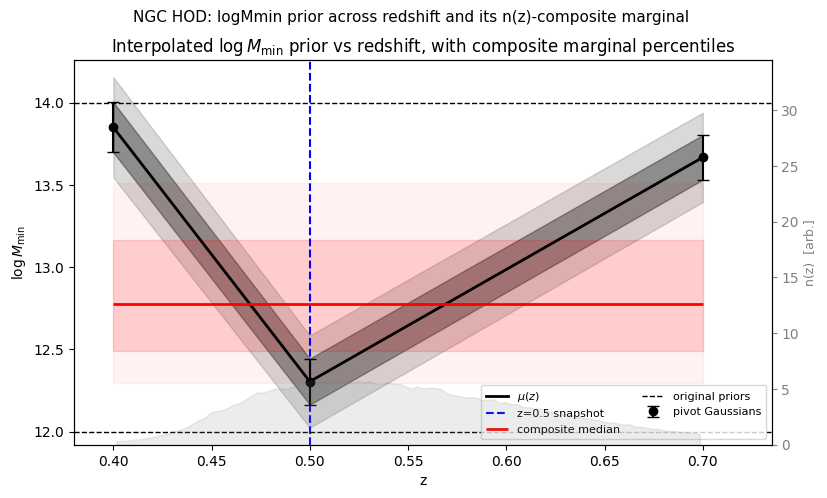

Saved figures/composite_hod_prior_interp_ngc.png


In [ ]:
from cmass.bias.tools.hod_models import linear_interp_extrap
prior_info = SURVEY_HOD_PRIORS['0.40,0.50,0.70'][SURVEY]
means = np.array(prior_info['mean'])
stdevs = np.array(prior_info['stdev'])
zpivot = np.array(ZPIVOT)

# Dense z grid for interpolated mean and sigma bands
z_grid = np.linspace(z_obs.min(), z_obs.max(), 500)

mu_z = linear_interp_extrap(z_grid, zpivot, means)
sigma_z = linear_interp_extrap(z_grid, zpivot, stdevs)

# n(z) density (for weighting / overlay)
nz_counts, nz_edges = np.histogram(z_obs, bins=100, density=True)
nz_centers = 0.5 * (nz_edges[:-1] + nz_edges[1:])

# Composite marginal percentiles
pct_levels = [2.5, 16, 50, 84, 97.5]
p2_5, p16, p50, p84, p97_5 = np.percentile(logMmin_composite, pct_levels)

fig, ax_main = plt.subplots(figsize=(9, 5))

# ── logMmin(z) interpolation ─────────────────────────────────────────────
# ±2σ and ±1σ bands
ax_main.fill_between(z_grid, mu_z - 2*sigma_z, mu_z + 2*sigma_z,
                     color='k', alpha=0.15)
ax_main.fill_between(z_grid, mu_z - sigma_z,   mu_z + sigma_z,
                     color='k', alpha=0.35)
ax_main.plot(z_grid, mu_z, color='k', lw=2, label=r'$\mu(z)$')

# Pivot points
ax_main.errorbar(zpivot, means, yerr=stdevs, fmt='o', color='k',
                 capsize=4, zorder=5, label='pivot Gaussians')

# z=0.5 snapshot line
ax_main.axvline(0.5, color='b', lw=1.5, ls='--', label='z=0.5 snapshot')

# Composite marginal percentile band — drawn as a horizontal strip
# off to the side of the main z range, e.g. just past z_grid.max()
band_x0 = z_grid.min()
band_width = (z_grid.max() - z_grid.min())
band_x1 = band_x0 + band_width

ax_main.fill_betweenx([p2_5, p97_5], band_x0, band_x1,
                      color='r', alpha=0.05)
ax_main.fill_betweenx([p16, p84], band_x0, band_x1,
                      color='r', alpha=0.15)
ax_main.hlines(p50, band_x0, band_x1, color='r', lw=2, zorder=5,
               label='composite median')

# extend xlim so the band is visible
ax_main.set_xlim(z_grid.min()*0.95, z_grid.max()*1.05)

# show original priors
ax_main.axhline(12, color='k', linestyle='--', linewidth=1)
ax_main.axhline(14, color='k', linestyle='--',
                linewidth=1, label='original priors')

# n(z) as a shaded rug on the bottom
ax_twin = ax_main.twinx()
ax_twin.fill_between(nz_centers, 0, nz_counts, color='grey', alpha=0.15)
ax_twin.set_ylabel('n(z)  [arb.]', color='grey', fontsize=9)
ax_twin.tick_params(axis='y', colors='grey')
ax_twin.set_ylim(0, nz_counts.max() * 6)  # push n(z) to bottom fifth

ax_main.set_xlabel('z')
ax_main.set_ylabel(r'$\log M_{\min}$')
ax_main.set_title(
    r'Interpolated $\log M_{\min}$ prior vs redshift, with composite marginal percentiles')
ax_main.legend(fontsize=8, ncol=2)

fig.suptitle(
    'NGC HOD: logMmin prior across redshift and its n(z)-composite marginal', fontsize=11)
plt.savefig('../figures/composite_hod_prior_interp_ngc.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/composite_hod_prior_interp_ngc.png')

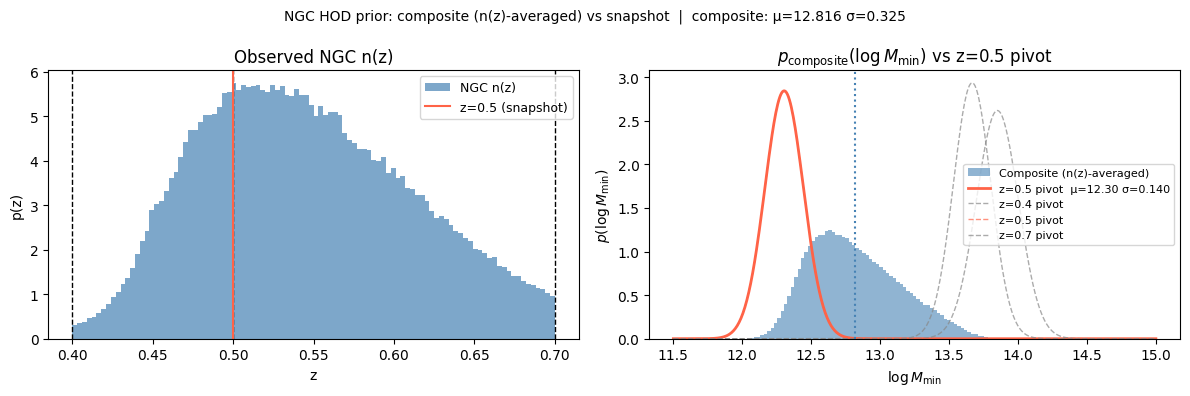

Saved figures/composite_hod_prior_ngc.png


In [7]:
prior_info = SURVEY_HOD_PRIORS['0.40,0.50,0.70'][SURVEY]
means = prior_info['mean']   # [mu_z0, mu_z1, mu_z2]
stdevs = prior_info['stdev']

x = np.linspace(11.5, 15.0, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: n(z) ---
ax = axes[0]
ax.hist(z_obs, bins=100, density=True,
        color='steelblue', alpha=0.7, label='NGC n(z)')
for zp in ZPIVOT:
    ax.axvline(zp, ls='--', color='k', lw=1)
ax.axvline(0.5, ls='-', color='tomato', lw=1.5, label='z=0.5 (snapshot)')
ax.set_xlabel('z')
ax.set_ylabel('p(z)')
ax.set_title('Observed NGC n(z)')
ax.legend(fontsize=9)

# --- Right: p(logMmin) ---
ax = axes[1]

# Composite prior from MC
ax.hist(logMmin_composite, bins=80, density=True,
        color='steelblue', alpha=0.6, label='Composite (n(z)-averaged)')

# z=0.5 pivot Gaussian
ax.plot(x, norm.pdf(x, means[1], stdevs[1]),
        color='tomato', lw=2, label=f'z=0.5 pivot  μ={means[1]:.2f} σ={stdevs[1]:.3f}')

# Individual pivot Gaussians (faint)
pivot_colors = ['#888888', 'tomato', '#888888']
for i, (mu, sig, zp) in enumerate(zip(means, stdevs, ZPIVOT)):
    ax.plot(x, norm.pdf(x, mu, sig), color=pivot_colors[i], lw=1, ls='--',
            label=f'z={zp} pivot', alpha=0.7)

mu_c, sig_c = logMmin_composite.mean(), logMmin_composite.std()
ax.axvline(mu_c, color='steelblue', lw=1.5, ls=':')
ax.set_xlabel(r'$\log M_{\min}$')
ax.set_ylabel(r'$p(\log M_{\min})$')
ax.set_title(r'$p_{\rm composite}(\log M_{\min})$ vs z=0.5 pivot')
ax.legend(fontsize=8)

fig.suptitle(
    f'NGC HOD prior: composite (n(z)-averaged) vs snapshot  |  '
    f'composite: μ={mu_c:.3f} σ={sig_c:.3f}',
    fontsize=10
)
plt.tight_layout()
plt.savefig('../figures/composite_hod_prior_ngc.png', dpi=150)
plt.show()
print('Saved figures/composite_hod_prior_ngc.png')

## Summary table

`logM0` and `logM1` are uniform over their bounds at all z — their composite prior
is identical to the per-snapshot prior.

In [8]:
print(f'{"Param":<20} {"z=0.5 mean":>12} {"z=0.5 std":>10} {"composite mean":>15} {"composite std":>13}')
print('-' * 75)

print(
    f'{"logMmin":<20} {means[1]:>12.4f} {stdevs[1]:>10.4f} {mu_c:>15.4f} {sig_c:>13.4f}')

for pname, lo, hi in [('logM0', 13.0, 15.0), ('logM1', 13.0, 15.0)]:
    mu_u = (lo + hi) / 2
    sig_u = (hi - lo) / np.sqrt(12)
    print(f'{pname:<20} {mu_u:>12.4f} {sig_u:>10.4f} {mu_u:>15.4f} {sig_u:>13.4f}  (uniform, z-indep)')

Param                  z=0.5 mean  z=0.5 std  composite mean composite std
---------------------------------------------------------------------------
logMmin                   12.3038     0.1403         12.8163        0.3246
logM0                     14.0000     0.5774         14.0000        0.5774  (uniform, z-indep)
logM1                     14.0000     0.5774         14.0000        0.5774  (uniform, z-indep)
